# Step 3.2 — Layer 1 Validation on Development Samples

## Objective
This notebook validates the Layer 1 rule-based detector on 6 selected development samples.

The goals are to:
- run Layer 1 on the selected development samples
- inspect the generated flags at the development-sample level
- check whether the rule outputs are reasonable
- review whether any threshold adjustment is needed

In this validation, samples are identified at the **development-sample level** rather than only by tester name, because one tester may appear in multiple videos or projects. Therefore, flags are filtered using the `(tester_name, project)` pair and then mapped to a unified `dev_sample_id`.

## Rules Under Validation

| Rule | Current Threshold | Flag |
|---|---|---|
| Video duration vs Timeguide | `duration_ratio < 0.3` or `> 3.0` | `DURATION_ANOMALY` |
| Silence ratio | `silence_ratio > 0.6` | `EXCESSIVE_SILENCE` |
| Transcription confidence | `avg_confidence < 0.7` | `LOW_AUDIO_QUALITY` |
| Narration density | `narration_density < 0.2` | `SPARSE_NARRATION` |

## Project Development Samples

| Project | Development Sample ID | Tester Name |
|---|---|---|
| Department of Premier and Cabinet (WA) | `ghum_wa` | `ghum` |
| Department of Premier and Cabinet (WA) | `reneerussell99_wa` | `reneerussell99` |
| Suncorp Insurance | `terryaflint17_suncorp` | `terryaflint17` |
| Suncorp Insurance | `carlpatrickrobinson_suncorp` | `carlpatrickrobinson` |
| University of Queensland | `ramazankawish_uq` | `ramazankawish` |
| University of Queensland | `jenniferparry7_uq` | `jenniferparry7` |

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

flags = pd.read_csv("data/processed/layer1_flags.csv")
audio = pd.read_csv("data/processed/audio_features.csv")
metadata = pd.read_csv("data/processed/video_metadata.csv")

DEV_SAMPLES = [
    {"video_id": "ghum_wa", "tester_name": "ghum", "project": "department-of-premier-and-cabinet-wa"},
    {"video_id": "reneerussell99_wa", "tester_name": "reneerussell99", "project": "department-of-premier-and-cabinet-wa"},
    {"video_id": "terryaflint17_suncorp", "tester_name": "terryaflint17", "project": "suncorp-insurance"},
    {"video_id": "carlpatrickrobinson_suncorp", "tester_name": "carlpatrickrobinson", "project": "suncorp-insurance"},
    {"video_id": "ramazankawish_uq", "tester_name": "ramazankawish", "project": "the-university-of-queensland"},
    {"video_id": "jenniferparry7_uq", "tester_name": "jenniferparry7", "project": "the-university-of-queensland"},
]

DEV_VIDEO_IDS = [x["video_id"] for x in DEV_SAMPLES]
dev_pairs = [(x["tester_name"], x["project"]) for x in DEV_SAMPLES]
sample_map = {(x["tester_name"], x["project"]): x["video_id"] for x in DEV_SAMPLES}

audio_dev = audio[audio["video_id"].isin(DEV_VIDEO_IDS)].copy()
meta_dev = metadata[
    metadata.apply(lambda r: (r["tester_name"], r["project"]) in dev_pairs, axis=1)
].copy()
flags_dev = flags[
    flags.apply(lambda r: (r["tester_name"], r["project"]) in dev_pairs, axis=1)
].copy()

flags_dev["dev_sample_id"] = flags_dev.apply(
    lambda r: sample_map.get((r["tester_name"], r["project"])),
    axis=1
)

meta_dev["dev_sample_id"] = meta_dev.apply(
    lambda r: sample_map.get((r["tester_name"], r["project"])),
    axis=1
)

print(f"audio_dev: {audio_dev.shape[0]} windows across {audio_dev['video_id'].nunique()} videos")
print(f"flags_dev: {flags_dev.shape[0]} flags")
print(f"meta_dev: {meta_dev.shape[0]} video records")


audio_dev: 331 windows across 6 videos
flags_dev: 66 flags
meta_dev: 6 video records


## 1. Overall Flag Summary

In [55]:
# Total flag counts by type
flag_counts = flags_dev["flag"].value_counts().reset_index()
flag_counts.columns = ["flag", "count"]
print("=== Flag counts by type ===")
print(flag_counts.to_string(index=False))

print()

# Flag counts per development sample
sample_flag_matrix = (
    flags_dev.groupby(["dev_sample_id", "flag"])
    .size()
    .unstack(fill_value=0)
    .reindex(DEV_VIDEO_IDS, fill_value=0)
)

print("=== Flags per development sample ===")
print(sample_flag_matrix.to_string())


=== Flag counts by type ===
             flag  count
EXCESSIVE_SILENCE     38
LOW_AUDIO_QUALITY     21
 SPARSE_NARRATION      5
 DURATION_ANOMALY      2

=== Flags per development sample ===
flag                         DURATION_ANOMALY  EXCESSIVE_SILENCE  LOW_AUDIO_QUALITY  SPARSE_NARRATION
dev_sample_id                                                                                        
ghum_wa                                     0                  0                  0                 0
reneerussell99_wa                           0                  0                  1                 0
terryaflint17_suncorp                       0                 38                 14                 5
carlpatrickrobinson_suncorp                 1                  0                  0                 0
ramazankawish_uq                            0                  0                  1                 0
jenniferparry7_uq                           1                  0                  5            

### Overall Flag Summary

The revised sample-level validation shows **66 total flags** across the 6 selected development samples.

Among the four Layer 1 rules:
- `EXCESSIVE_SILENCE` is the most frequent flag (**38**),
- followed by `LOW_AUDIO_QUALITY` (**21**),
- `SPARSE_NARRATION` (**5**),
- and `DURATION_ANOMALY` (**2**).

Most flags are concentrated in `terryaflint17_suncorp`, which suggests that the detector is identifying a clearly problematic sample rather than assigning flags uniformly across all cases. At the same time, some samples such as `ghum_wa` receive no flags at all, which supports the selectivity of the rule-based detector.

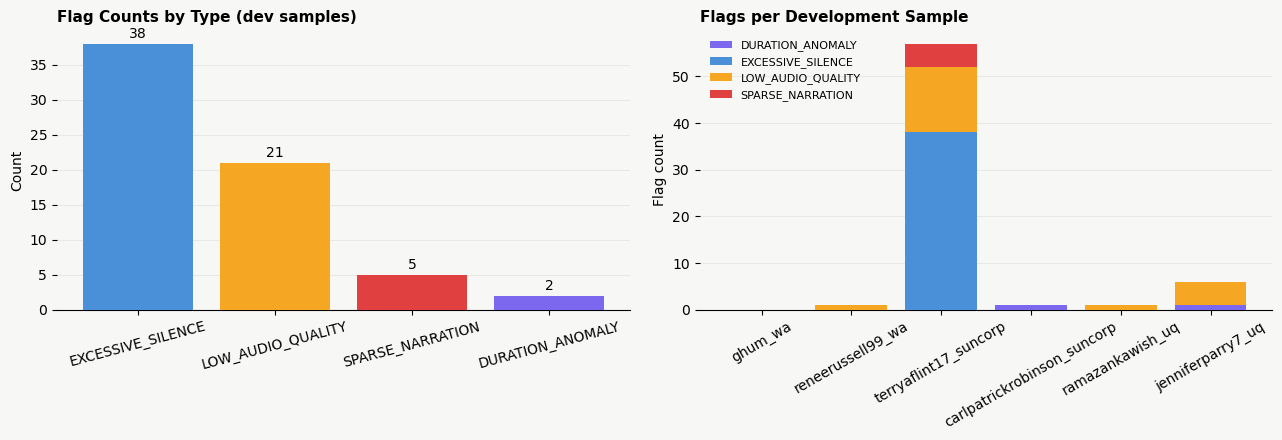

In [56]:
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor("#F7F7F5")

FLAG_COLORS = {
    "EXCESSIVE_SILENCE": "#4A90D9",
    "SPARSE_NARRATION": "#E04040",
    "LOW_AUDIO_QUALITY": "#F5A623",
    "DURATION_ANOMALY": "#7B68EE",
}

# Left
ax = axes[0]
ax.set_facecolor("#F7F7F5")
colors = [FLAG_COLORS.get(f, "#999") for f in flag_counts["flag"]]
bars = ax.bar(flag_counts["flag"], flag_counts["count"], color=colors, zorder=3)
ax.set_title("Flag Counts by Type (dev samples)", fontsize=11, fontweight="bold", loc="left")
ax.set_ylabel("Count")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="y", color="#E8E8E4")
ax.set_axisbelow(True)
ax.tick_params(axis="x", rotation=15)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        str(int(bar.get_height())),
        ha="center",
        fontsize=10
    )

# Right
ax2 = axes[1]
ax2.set_facecolor("#F7F7F5")
flag_cols = sample_flag_matrix.columns.tolist()
bottom = np.zeros(len(sample_flag_matrix))

for col in flag_cols:
    vals = sample_flag_matrix[col].values
    ax2.bar(
        sample_flag_matrix.index,
        vals,
        bottom=bottom,
        label=col,
        color=FLAG_COLORS.get(col, "#999"),
        zorder=3
    )
    bottom += vals

ax2.set_title("Flags per Development Sample", fontsize=11, fontweight="bold", loc="left")
ax2.set_ylabel("Flag count")
ax2.spines[["top", "right", "left"]].set_visible(False)
ax2.grid(axis="y", color="#E8E8E4")
ax2.set_axisbelow(True)
ax2.tick_params(axis="x", rotation=30)
ax2.legend(fontsize=8, frameon=False, loc="upper left")

plt.tight_layout()
plt.show()

The sample-level chart includes all 6 development samples. Among them, `terryaflint17_suncorp` accounts for the majority of triggered flags, especially `EXCESSIVE_SILENCE`, while `ghum_wa` has zero triggered flags under the current Layer 1 rules.

This pattern suggests that the rule-based detector is selectively identifying problematic samples rather than assigning flags uniformly across all development cases.

## 2. Rule Validation — `DURATION_ANOMALY`
**Threshold:** `duration_ratio < 0.3` or `duration_ratio > 3.0`

`duration_ratio` = actual video duration ÷ Timeguide expected duration.
A ratio < 0.3 means the recording is less than 30% of the expected length — likely an incomplete session.

In [80]:
da_flags = flags_dev[flags_dev["flag"] == "DURATION_ANOMALY"].copy()

print("=== DURATION_ANOMALY flags ===")
print(
    da_flags[["dev_sample_id", "tester_name", "project", "value"]]
    .sort_values("value")
    .to_string(index=False)
)

print()
print("=== All development sample duration ratios ===")
print(
    meta_dev[["dev_sample_id", "tester_name", "project", "duration_seconds", "duration_ratio"]]
    .sort_values("duration_ratio")
    .to_string(index=False)
)

=== DURATION_ANOMALY flags ===
              dev_sample_id         tester_name                      project  value
carlpatrickrobinson_suncorp carlpatrickrobinson            suncorp-insurance 0.1442
          jenniferparry7_uq      jenniferparry7 the-university-of-queensland 0.1588

=== All development sample duration ratios ===
              dev_sample_id         tester_name                              project  duration_seconds  duration_ratio
carlpatrickrobinson_suncorp carlpatrickrobinson                    suncorp-insurance           1042.23          0.1442
          jenniferparry7_uq      jenniferparry7         the-university-of-queensland           1581.20          0.1588
          reneerussell99_wa      reneerussell99 department-of-premier-and-cabinet-wa           4223.70          0.5374
      terryaflint17_suncorp       terryaflint17                    suncorp-insurance           5055.30          0.6992
                    ghum_wa                ghum department-of-premier-and-

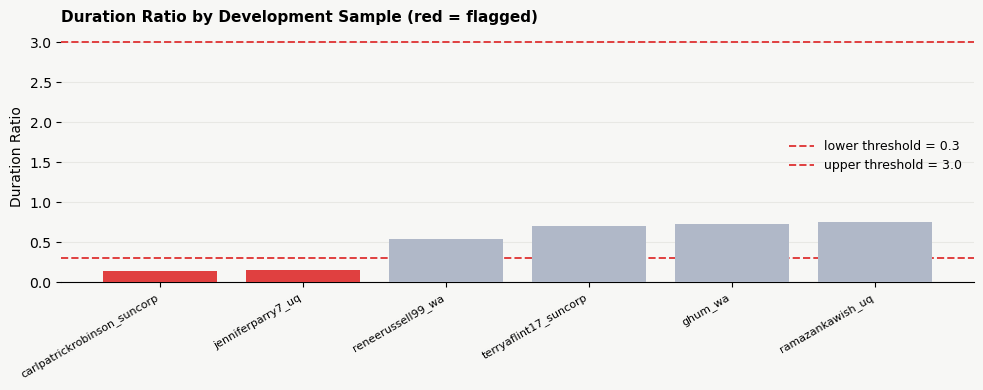

In [81]:
# Visualise all duration ratios, highlight flagged samples
meta_plot = meta_dev.sort_values("duration_ratio").copy()

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor("#F7F7F5")
ax.set_facecolor("#F7F7F5")

colors = ["#E04040" if (r < 0.3 or r > 3.0) else "#B0B8C8"
          for r in meta_plot["duration_ratio"]]

labels = meta_plot["dev_sample_id"].tolist()

bars = ax.bar(
    range(len(meta_plot)),
    meta_plot["duration_ratio"].values,
    color=colors,
    zorder=3
)

ax.set_xticks(range(len(meta_plot)))
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax.axhline(0.3, color="#E04040", linestyle="--", linewidth=1.4, label="lower threshold = 0.3")
ax.axhline(3.0, color="#E04040", linestyle="--", linewidth=1.4, label="upper threshold = 3.0")
ax.set_ylabel("Duration Ratio")
ax.set_title("Duration Ratio by Development Sample (red = flagged)", fontsize=11, fontweight="bold", loc="left")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="y", color="#E8E8E4")
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

### Manual Check — `DURATION_ANOMALY`

| Development Sample | Project | duration_ratio | Assessment |
|---|---|---:|---|
| `carlpatrickrobinson_suncorp` | Suncorp | 0.1442 | ✅ Correctly flagged — the recording is only about 14% of the expected length, suggesting an incomplete session. |
| `jenniferparry7_uq` | UQ | 0.1588 | ✅ Correctly flagged — the recording is also far below the 0.3 threshold and is likely incomplete. |

All other development samples have duration ratios between **0.54 and 0.76**. None of them are close to the lower threshold of **0.3**, and no sample exceeds the upper threshold of **3.0**.

**Verdict: The current duration threshold is appropriate.**  
The two flagged cases are genuine short recordings and are both well below the lower threshold of **0.3**. No false positives are observed in the selected development samples. The upper bound (**> 3.0**) does not trigger in this dev set, but it can continue to be monitored on the full dataset.

## 3. Rule Validation — `EXCESSIVE_SILENCE`
**Threshold:** `silence_ratio > 0.6`


In [82]:
audio_dev = audio_dev.copy()
audio_dev["dev_sample_id"] = audio_dev["video_id"]

es_flags = flags_dev[flags_dev["flag"] == "EXCESSIVE_SILENCE"].copy()

print(f"Total EXCESSIVE_SILENCE flags: {len(es_flags)}")
print(f"Development samples flagged: {es_flags['dev_sample_id'].unique()}")

print()
print("=== silence_ratio distribution (dev windows) ===")
print(audio_dev["silence_ratio"].describe().round(4))

print()
print("=== Mean silence_ratio per development sample ===")
print(
    audio_dev.groupby("dev_sample_id")["silence_ratio"]
    .agg(["mean", "max", "count"])
    .round(3)
)

print()
print("=== EXCESSIVE_SILENCE threshold sensitivity ===")
for thresh in [0.4, 0.5, 0.6, 0.7, 0.8]:
    n = (audio_dev["silence_ratio"] > thresh).sum()
    samples_hit = audio_dev[audio_dev["silence_ratio"] > thresh]["dev_sample_id"].nunique()
    print(f"> {thresh}: {n:3d} windows ({n/len(audio_dev)*100:.1f}%) across {samples_hit} development sample(s)")

Total EXCESSIVE_SILENCE flags: 38
Development samples flagged: ['terryaflint17_suncorp']

=== silence_ratio distribution (dev windows) ===
count    331.0000
mean       0.1651
std        0.2540
min        0.0000
25%        0.0000
50%        0.0138
75%        0.2213
max        0.8771
Name: silence_ratio, dtype: float64

=== Mean silence_ratio per development sample ===
                              mean    max  count
dev_sample_id                                   
carlpatrickrobinson_suncorp  0.002  0.019     15
ghum_wa                      0.050  0.190     83
jenniferparry7_uq            0.220  0.379     23
ramazankawish_uq             0.001  0.030    104
reneerussell99_wa            0.007  0.061     33
terryaflint17_suncorp        0.618  0.877     73

=== EXCESSIVE_SILENCE threshold sensitivity ===
> 0.4:  73 windows (22.1%) across 1 development sample(s)
> 0.5:  62 windows (18.7%) across 1 development sample(s)
> 0.6:  38 windows (11.5%) across 1 development sample(s)
> 0.7:  15 wind

C:\Users\Sialiang\AppData\Local\Temp\ipykernel_11296\3163657290.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_by_sample, labels=sample_order, patch_artist=True, vert=True)


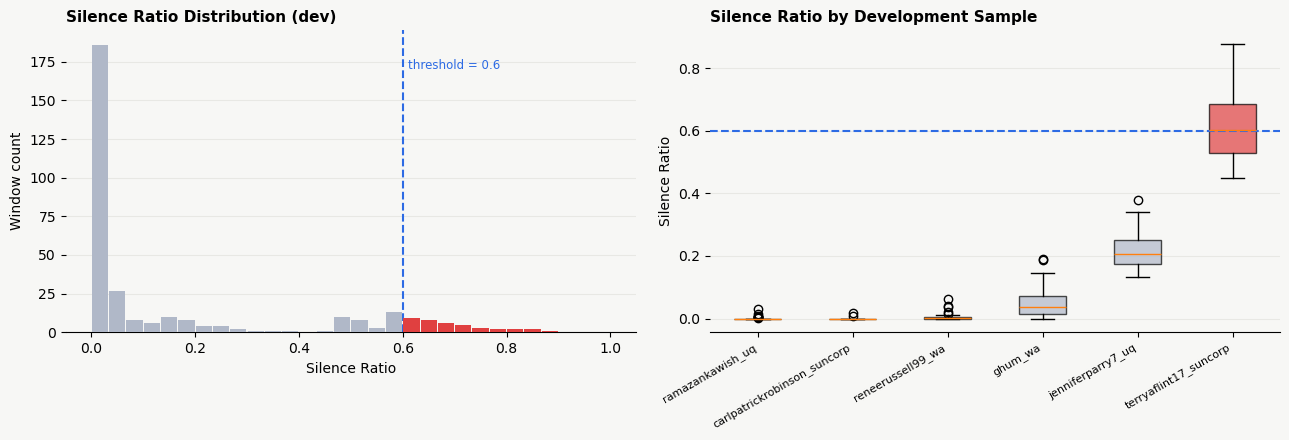

In [83]:
# Visualise silence_ratio distribution with threshold lines
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor("#F7F7F5")

# Left: histogram
ax = axes[0]
ax.set_facecolor("#F7F7F5")
bins = np.linspace(0, 1, 31)
bw = bins[1] - bins[0] - 0.002
counts_all, _ = np.histogram(audio_dev["silence_ratio"], bins=bins)
bc = (bins[:-1] + bins[1:]) / 2

ax.bar(bc[bc <= 0.6], counts_all[bc <= 0.6], width=bw, color="#B0B8C8", zorder=3)
ax.bar(bc[bc > 0.6], counts_all[bc > 0.6], width=bw, color="#E04040", zorder=3)
ax.axvline(0.6, color="#2D6BE4", linestyle="--", linewidth=1.5)
ax.text(0.61, counts_all.max() * 0.95, "threshold = 0.6",
        color="#2D6BE4", fontsize=8.5, va="top")

ax.set_xlabel("Silence Ratio")
ax.set_ylabel("Window count")
ax.set_title("Silence Ratio Distribution (dev)", fontsize=11, fontweight="bold", loc="left")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="y", color="#E8E8E4")
ax.set_axisbelow(True)

# Right: per-sample boxplot
ax2 = axes[1]
ax2.set_facecolor("#F7F7F5")
sample_order = (
    audio_dev.groupby("dev_sample_id")["silence_ratio"]
    .mean()
    .sort_values()
    .index
)

data_by_sample = [
    audio_dev[audio_dev["dev_sample_id"] == s]["silence_ratio"].values
    for s in sample_order
]

bp = ax2.boxplot(data_by_sample, labels=sample_order, patch_artist=True, vert=True)

for patch, s in zip(bp["boxes"], sample_order):
    mean_val = audio_dev[audio_dev["dev_sample_id"] == s]["silence_ratio"].mean()
    patch.set_facecolor("#E04040" if mean_val > 0.6 else "#B0B8C8")
    patch.set_alpha(0.7)

ax2.axhline(0.6, color="#2D6BE4", linestyle="--", linewidth=1.5)
ax2.set_xticklabels(sample_order, rotation=30, ha="right", fontsize=8)
ax2.set_ylabel("Silence Ratio")
ax2.set_title("Silence Ratio by Development Sample", fontsize=11, fontweight="bold", loc="left")
ax2.spines[["top", "right", "left"]].set_visible(False)
ax2.grid(axis="y", color="#E8E8E4")
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 📋 Manual Check — `EXCESSIVE_SILENCE`

All **38** `EXCESSIVE_SILENCE` flags in the selected development samples belong to **`terryaflint17_suncorp`** only.

This development sample has a mean `silence_ratio` of **0.618**, which is clearly the highest among the 6 selected development samples. All other development samples have mean silence ratios below **0.22**, and none of them trigger the current threshold.

### Threshold sensitivity

| Threshold | Windows flagged | Development samples affected |
|---|---:|---:|
| `> 0.5` | 62 (18.7%) | 1 |
| `> 0.6` **(current)** | 38 (11.5%) | 1 |
| `> 0.7` | 15 (4.5%) | 1 |
| `> 0.8` | 5 (1.5%) | 1 |

The current threshold of **0.6** appears to work reasonably well in the selected development samples. It captures a substantial number of highly silent windows in `terryaflint17_suncorp` without generating false positives in the other 5 development samples.

**Verdict: The current silence threshold is appropriate.**  
The threshold `silence_ratio > 0.6` identifies a clearly problematic development sample while remaining selective on the rest of the dev set. Lowering the threshold to **0.5** would increase sensitivity, but it would also substantially increase the number of flagged windows. At this stage, keeping the current threshold at **0.6** is reasonable, while further monitoring can be done on the full dataset.


## 4. Rule Validation — `LOW_AUDIO_QUALITY`
**Threshold:** `avg_confidence < 0.7`

In [84]:
audio_dev = audio_dev.copy()
audio_dev["dev_sample_id"] = audio_dev["video_id"]
laq_flags = flags_dev[flags_dev["flag"] == "LOW_AUDIO_QUALITY"].copy()

print(f"Total LOW_AUDIO_QUALITY flags: {len(laq_flags)}")
print(f"Development samples flagged: {sorted(laq_flags['dev_sample_id'].unique())}")

print()
print("=== Flagged windows ===")
print(
    laq_flags[["dev_sample_id", "window_id", "start_time", "end_time", "value"]]
    .sort_values(["dev_sample_id", "start_time"])
    .to_string(index=False)
)

print()
print("=== avg_confidence distribution (dev windows) ===")
print(audio_dev["avg_confidence"].describe().round(4))

print()
print("=== Mean avg_confidence per development sample ===")
print(
    audio_dev.groupby("dev_sample_id")["avg_confidence"]
    .agg(["mean", "min", "count"])
    .round(3)
)

print()
print("=== LOW_AUDIO_QUALITY threshold sensitivity ===")
for thresh in [0.65, 0.70, 0.75, 0.80]:
    n = (audio_dev["avg_confidence"] < thresh).sum()
    samples = audio_dev[audio_dev["avg_confidence"] < thresh]["dev_sample_id"].nunique()
    print(f"< {thresh}: {n:3d} windows ({n/len(audio_dev)*100:.1f}%) across {samples} development sample(s)")

Total LOW_AUDIO_QUALITY flags: 21
Development samples flagged: ['jenniferparry7_uq', 'ramazankawish_uq', 'reneerussell99_wa', 'terryaflint17_suncorp']

=== Flagged windows ===
        dev_sample_id                  window_id  start_time  end_time  value
    jenniferparry7_uq     jenniferparry7_uq_w016    1079.349  1141.790 0.6981
    jenniferparry7_uq     jenniferparry7_uq_w018    1211.839  1276.859 0.5963
    jenniferparry7_uq     jenniferparry7_uq_w019    1277.469  1337.849 0.6912
    jenniferparry7_uq     jenniferparry7_uq_w020    1338.660  1401.010 0.6219
    jenniferparry7_uq     jenniferparry7_uq_w022    1483.239  1580.000 0.6636
     ramazankawish_uq      ramazankawish_uq_w060    4300.419  4360.569 0.6593
    reneerussell99_wa     reneerussell99_wa_w031    4064.239  4128.560 0.1547
terryaflint17_suncorp terryaflint17_suncorp_w009     590.369   652.260 0.6691
terryaflint17_suncorp terryaflint17_suncorp_w030    1992.939  2056.370 0.6862
terryaflint17_suncorp terryaflint17_suncorp_

C:\Users\Sialiang\AppData\Local\Temp\ipykernel_11296\2682139748.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_by_sample, labels=sample_order, patch_artist=True)


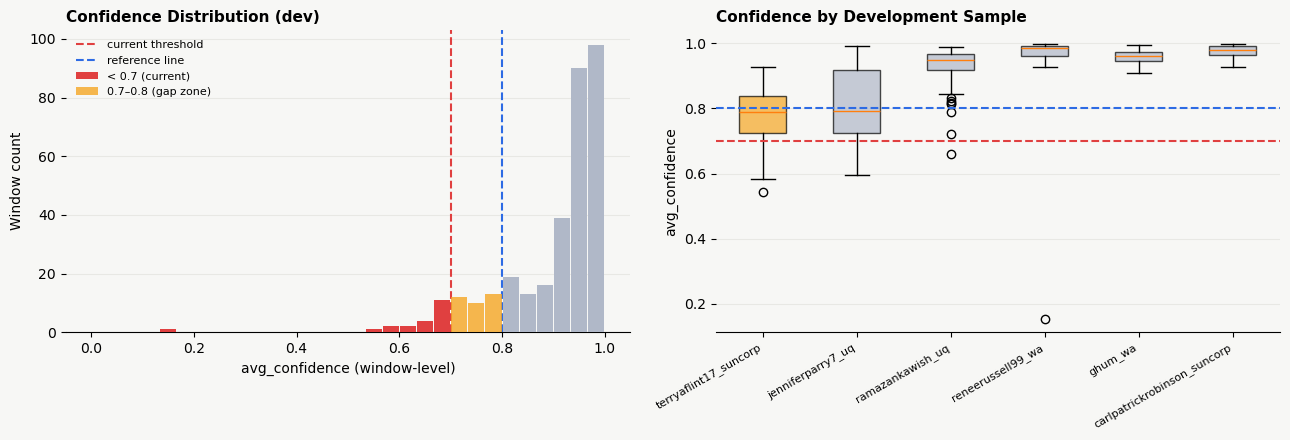

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor("#F7F7F5")

# Left: histogram
ax = axes[0]
ax.set_facecolor("#F7F7F5")
bins = np.linspace(0, 1, 31)
bw = bins[1] - bins[0] - 0.002
counts_all, _ = np.histogram(audio_dev["avg_confidence"], bins=bins)
bc = (bins[:-1] + bins[1:]) / 2

ax.bar(bc[bc >= 0.8], counts_all[bc >= 0.8], width=bw, color="#B0B8C8", zorder=3)
ax.bar(bc[bc < 0.7], counts_all[bc < 0.7], width=bw, color="#E04040", zorder=3, label="< 0.7 (current)")
ax.bar(
    bc[(bc >= 0.7) & (bc < 0.8)],
    counts_all[(bc >= 0.7) & (bc < 0.8)],
    width=bw, color="#F5A623", zorder=3, alpha=0.8, label="0.7–0.8 (gap zone)"
)

ax.axvline(0.7, color="#E04040", linestyle="--", linewidth=1.5, label="current threshold")
ax.axvline(0.8, color="#2D6BE4", linestyle="--", linewidth=1.5, label="reference line")
ax.set_xlabel("avg_confidence (window-level)")
ax.set_ylabel("Window count")
ax.set_title("Confidence Distribution (dev)", fontsize=11, fontweight="bold", loc="left")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="y", color="#E8E8E4")
ax.set_axisbelow(True)

# Right: per-sample boxplot
ax2 = axes[1]
ax2.set_facecolor("#F7F7F5")
sample_order = (
    audio_dev.groupby("dev_sample_id")["avg_confidence"]
    .mean()
    .sort_values()
    .index
)

data_by_sample = [
    audio_dev[audio_dev["dev_sample_id"] == s]["avg_confidence"].values
    for s in sample_order
]

bp = ax2.boxplot(data_by_sample, labels=sample_order, patch_artist=True)

for patch, s in zip(bp["boxes"], sample_order):
    mean_v = audio_dev[audio_dev["dev_sample_id"] == s]["avg_confidence"].mean()
    patch.set_facecolor(
        "#E04040" if mean_v < 0.7 else
        "#F5A623" if mean_v < 0.8 else
        "#B0B8C8"
    )
    patch.set_alpha(0.7)

ax2.axhline(0.7, color="#E04040", linestyle="--", linewidth=1.5)
ax2.axhline(0.8, color="#2D6BE4", linestyle="--", linewidth=1.5)
ax2.set_xticklabels(sample_order, rotation=30, ha="right", fontsize=8)
ax2.set_ylabel("avg_confidence")
ax2.set_title("Confidence by Development Sample", fontsize=11, fontweight="bold", loc="left")
ax2.spines[["top", "right", "left"]].set_visible(False)
ax2.grid(axis="y", color="#E8E8E4")
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 📋 Manual Check — `LOW_AUDIO_QUALITY`

**Flagged windows at the current threshold (`avg_confidence < 0.7`): 21 windows (6.3%)**

| Development Sample | Windows flagged | Notes |
|---|---:|---|
| `reneerussell99_wa` | 1 | A single extreme outlier at **0.1547**, which is very likely a genuine low-quality segment. |
| `jenniferparry7_uq` | 5 | Several borderline low-confidence windows, suggesting mild but recurring audio-quality issues. |
| `ramazankawish_uq` | 1 | One isolated low-confidence window (**0.6593**). |
| `terryaflint17_suncorp` | 14 | A consistent pattern of lower-confidence windows, aligned with the heavy silence pattern observed in the same development sample. |

### Threshold sensitivity

| Threshold | Windows flagged | Development samples affected |
|---|---:|---:|
| `< 0.65` | 7 (2.1%) | 3 |
| `< 0.7` **(current)** | 21 (6.3%) | 4 |
| `< 0.75` | 40 (12.1%) | 4 |
| `< 0.8` | 56 (16.9%) | 4 |

A substantial number of windows fall into the borderline range between **0.7 and 0.8**, which the current threshold does not capture. Raising the threshold from **0.7** to **0.75** would add **19** additional windows while keeping the affected development samples unchanged at **4**.

The flag in `reneerussell99_wa` at **0.1547** is a genuine extreme and would be detected under any reasonable threshold.  
The patterns in `jenniferparry7_uq` and especially `terryaflint17_suncorp` suggest that the current threshold of **0.7** may be slightly too permissive and may miss some borderline low-quality windows.

**Verdict: The current threshold `avg_confidence < 0.7` is likely too permissive.**  
A revised threshold of **`avg_confidence < 0.75`** appears to be a reasonable compromise. It increases coverage from **21 to 40 windows** while remaining more conservative than a full shift to **0.8**.


## 5. Rule Validation — `SPARSE_NARRATION`
**Threshold:** `narration_density < 0.2`


In [87]:
audio_dev = audio_dev.copy()
audio_dev["dev_sample_id"] = audio_dev["video_id"]

sn_flags = flags_dev[flags_dev["flag"] == "SPARSE_NARRATION"].copy()

print(f"Total SPARSE_NARRATION flags: {len(sn_flags)}")
print(f"Development samples flagged: {sorted(sn_flags['dev_sample_id'].unique())}")

print()
print("=== narration_density distribution (dev windows) ===")
print(audio_dev["narration_density"].describe().round(4))

print()
print("=== Mean narration_density per development sample ===")
print(
    audio_dev.groupby("dev_sample_id")["narration_density"]
    .agg(["mean", "min", "count"])
    .round(3)
)

print()
print("=== SPARSE_NARRATION threshold sensitivity ===")
for thresh in [0.15, 0.20, 0.25, 0.30, 0.35]:
    n = (audio_dev["narration_density"] < thresh).sum()
    samples = audio_dev[audio_dev["narration_density"] < thresh]["dev_sample_id"].nunique()
    print(
        f"< {thresh}: {n:3d} windows ({n/len(audio_dev)*100:.1f}%) "
        f"across {samples} development sample(s)"
    )

Total SPARSE_NARRATION flags: 5
Development samples flagged: ['terryaflint17_suncorp']

=== narration_density distribution (dev windows) ===
count    331.0000
mean       0.8349
std        0.2540
min        0.1229
25%        0.7787
50%        0.9862
75%        1.0000
max        1.0000
Name: narration_density, dtype: float64

=== Mean narration_density per development sample ===
                              mean    min  count
dev_sample_id                                   
carlpatrickrobinson_suncorp  0.998  0.981     15
ghum_wa                      0.950  0.810     83
jenniferparry7_uq            0.780  0.621     23
ramazankawish_uq             0.999  0.970    104
reneerussell99_wa            0.993  0.939     33
terryaflint17_suncorp        0.382  0.123     73

=== SPARSE_NARRATION threshold sensitivity ===
< 0.15:   3 windows (0.9%) across 1 development sample(s)
< 0.2:   5 windows (1.5%) across 1 development sample(s)
< 0.25:   8 windows (2.4%) across 1 development sample(s)
< 0.3: 

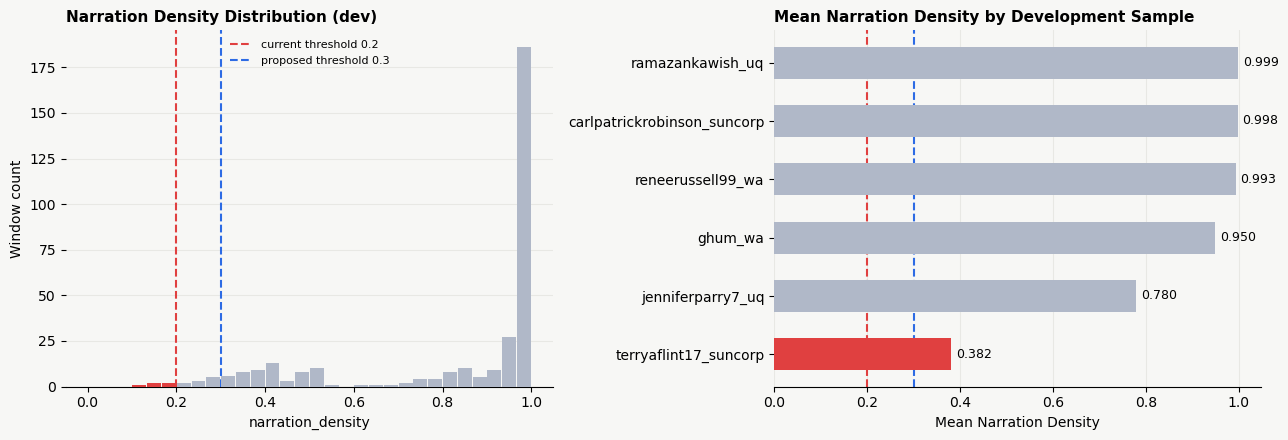

In [88]:
# Visualise narration density
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor("#F7F7F5")

# Left: histogram
ax = axes[0]
ax.set_facecolor("#F7F7F5")
bins = np.linspace(0, 1, 31)
bw = bins[1] - bins[0] - 0.002
counts_all, _ = np.histogram(audio_dev["narration_density"], bins=bins)
bc = (bins[:-1] + bins[1:]) / 2

ax.bar(bc[bc >= 0.2], counts_all[bc >= 0.2], width=bw, color="#B0B8C8", zorder=3)
ax.bar(bc[bc < 0.2], counts_all[bc < 0.2], width=bw, color="#E04040", zorder=3)
ax.axvline(0.20, color="#E04040", linestyle="--", linewidth=1.5, label="current threshold 0.2")
ax.axvline(0.30, color="#2D6BE4", linestyle="--", linewidth=1.5, label="proposed threshold 0.3")

ax.set_xlabel("narration_density")
ax.set_ylabel("Window count")
ax.set_title("Narration Density Distribution (dev)", fontsize=11, fontweight="bold", loc="left")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="y", color="#E8E8E4")
ax.set_axisbelow(True)

# Right: mean narration density by development sample
ax2 = axes[1]
ax2.set_facecolor("#F7F7F5")

sample_means = (
    audio_dev.groupby("dev_sample_id")["narration_density"]
    .mean()
    .sort_values()
)

colors = ["#E04040" if v < 0.5 else "#B0B8C8" for v in sample_means.values]
bars = ax2.barh(sample_means.index, sample_means.values, color=colors, height=0.55, zorder=3)

ax2.axvline(0.20, color="#E04040", linestyle="--", linewidth=1.5)
ax2.axvline(0.30, color="#2D6BE4", linestyle="--", linewidth=1.5)

for bar, val in zip(bars, sample_means.values):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center", fontsize=9)

ax2.set_xlabel("Mean Narration Density")
ax2.set_title("Mean Narration Density by Development Sample", fontsize=11, fontweight="bold", loc="left")
ax2.spines[["top", "right", "left"]].set_visible(False)
ax2.grid(axis="x", color="#E8E8E4")
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 📋 Manual Check — `SPARSE_NARRATION`

**Flagged at the current threshold (`narration_density < 0.2`): 5 windows (1.5%), all from `terryaflint17_suncorp`.**

The flagged windows in `terryaflint17_suncorp` fall clearly below the current threshold, with the minimum observed `narration_density` reaching **0.123**. This is consistent with a genuinely sparse-narration pattern rather than an isolated borderline case.

All other development samples have much higher mean narration density values:
- `jenniferparry7_uq`: **0.780**
- `ghum_wa`: **0.950**
- `reneerussell99_wa`: **0.993**
- `carlpatrickrobinson_suncorp`: **0.998**
- `ramazankawish_uq`: **0.999**

This means there are no competing borderline cases near the current threshold among the other selected development samples.

### Threshold sensitivity

| Threshold | Windows flagged | Development samples affected |
|---|---:|---:|
| `< 0.20` **(current)** | 5 (1.5%) | 1 |
| `< 0.25` | 8 (2.4%) | 1 |
| `< 0.30` | 15 (4.5%) | 1 |
| `< 0.35` | 25 (7.6%) | 1 |

The threshold sensitivity analysis shows that increasing the threshold would capture more sparse-narration windows, but all additional windows still come from the same development sample, `terryaflint17_suncorp`. In the current dev set, raising the threshold does not introduce any new affected samples.

The distribution is strongly separated: `terryaflint17_suncorp` occupies the low-density region, while the other five development samples remain far higher. This suggests that the current threshold of **0.2** is selective and does not create false positives.

**Verdict: The current threshold `narration_density < 0.2` is functional but conservative.**  
A revised threshold of **`narration_density < 0.3`** appears reasonable for better coverage, because it would capture more of the sparse-narration pattern in `terryaflint17_suncorp` while still affecting only the same development sample in this validation set.

## 6. Validation Summary & Threshold Adjustment Record

### 6.1 Rule Assessment

| Rule | Flag | Current Threshold | Verdict | Recommended Threshold |
|---|---|---|---|---|
| Duration vs Timeguide | `DURATION_ANOMALY` | `< 0.3` or `> 3.0` | ✅ Appropriate | No change |
| Silence ratio | `EXCESSIVE_SILENCE` | `> 0.6` | ✅ Appropriate | No change |
| Transcription confidence | `LOW_AUDIO_QUALITY` | `< 0.7` | ⚠️ Too permissive | Raise to `< 0.75` |
| Narration density | `SPARSE_NARRATION` | `< 0.2` | ⚠️ Functional but conservative | Raise to `< 0.3` |

### 6.2 Key Observations

**`terryaflint17_suncorp`** is the primary flagged development sample in this validation set. It accounts for all **38** `EXCESSIVE_SILENCE` flags, all **5** `SPARSE_NARRATION` flags, and **14** of the **21** `LOW_AUDIO_QUALITY` flags. This is consistent with the earlier EDA findings and suggests a genuine pattern of recording and narration issues rather than false positives.

**`carlpatrickrobinson_suncorp`** and **`jenniferparry7_uq`** are the two development samples flagged for `DURATION_ANOMALY`, with duration ratios of approximately **0.144** and **0.159** respectively. These are clearly below the lower threshold of **0.3**, indicating genuinely short or incomplete recordings.

`LOW_AUDIO_QUALITY` is more distributed across the dev set than the other flags. In addition to `terryaflint17_suncorp`, it also appears in **`reneerussell99_wa`** (1 window), **`jenniferparry7_uq`** (5 windows), and **`ramazankawish_uq`** (1 window). The threshold sensitivity analysis suggests that the current threshold of **0.7** may be too permissive and that **0.75** would better capture borderline low-quality windows.

For `SPARSE_NARRATION`, all flagged windows come from **`terryaflint17_suncorp`**. Raising the threshold from **0.2** to **0.3** would increase coverage from **5** to **15** windows while still affecting only the same development sample in this validation set.

### 6.3 Proposed Rule Table (v2)

| Rule | Flag | Threshold v1 | Threshold v2 | Change |
|---|---|---|---|---|
| Duration vs Timeguide | `DURATION_ANOMALY` | `< 0.3` or `> 3.0` | `< 0.3` or `> 3.0` | — |
| Silence ratio | `EXCESSIVE_SILENCE` | `> 0.6` | `> 0.6` | — |
| Transcription confidence | `LOW_AUDIO_QUALITY` | `< 0.7` | `< 0.75` | ↑ |
| Narration density | `SPARSE_NARRATION` | `< 0.2` | `< 0.3` | ↑ |